# Walmart Retail Sales - Pandas Insights Analysis
**Project:** Retail Sales Demand Forecasting & Intelligence Suite  
**Author:** Rishikesh K Sivaji

---
### What this notebook does
Pure pandas analysis answering business questions using groupby, pivot tables and aggregations.  
4 key visualizations are included at the most important findings.  
All charts saved to `outputs/pandas_insights/`

---
### Sections
1. Load Data and Setup
2. Store Performance Insights
3. Department Insights
4. Seasonality Insights
5. Holiday Insights
6. Markdown Insights
7. External Factor Insights
8. Final Summary


## 1. Load Data and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6']
os.makedirs('outputs/pandas_insights', exist_ok=True)

print("Setup done")


Setup done


In [2]:
df = pd.read_csv('data/master_df.csv', parse_dates=['Date'])
print(f"Shape : {df.shape}")
display(df.head(3))


Shape : (421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,MarkDown5,CPI,Unemployment,Year,Month,Month_Name,Week,Quarter,Total_Markdown,Markdown_Active
0,1,1,2010-02-05,"24,924.50",False,A,151315,42.31,2.57,0.00,...,0.00,211.10,8.11,2010,2,Feb,5,1,0.00,False
1,1,1,2010-02-12,"46,039.49",True,A,151315,38.51,2.55,0.00,...,0.00,211.24,8.11,2010,2,Feb,6,1,0.00,False
2,1,1,2010-02-19,"41,595.55",False,A,151315,39.93,2.51,0.00,...,0.00,211.29,8.11,2010,2,Feb,7,1,0.00,False


## 2. Store Performance Insights

In [3]:
# Top 10 and Bottom 10 stores by total sales
store_sales = (df.groupby(['Store','Type'])['Weekly_Sales']
               .sum()
               .reset_index()
               .sort_values('Weekly_Sales', ascending=False)
               .reset_index(drop=True))

store_sales['Total_Sales_M'] = (store_sales['Weekly_Sales'] / 1e6).round(2)
store_sales['Rank'] = store_sales.index + 1

print("TOP 10 STORES BY TOTAL SALES")
print("=" * 45)
print(store_sales[['Rank','Store','Type','Total_Sales_M']].head(10).to_string(index=False))

print()
print("BOTTOM 10 STORES BY TOTAL SALES")
print("=" * 45)
bot10 = store_sales.tail(10).copy()
bot10['Rank'] = range(36, 46)
print(bot10[['Rank','Store','Type','Total_Sales_M']].to_string(index=False))

gap = store_sales.iloc[0]['Total_Sales_M'] - store_sales.iloc[-1]['Total_Sales_M']
print(f"\nGap between #1 and #45 store : ${gap:.1f}M")


TOP 10 STORES BY TOTAL SALES
 Rank  Store Type  Total_Sales_M
    1     20    A         301.40
    2      4    A         299.55
    3     14    A         289.00
    4     13    A         286.52
    5      2    A         275.39
    6     10    B         271.62
    7     27    A         253.86
    8      6    A         223.76
    9      1    A         222.41
   10     39    A         207.45

BOTTOM 10 STORES BY TOTAL SALES
 Rank  Store Type  Total_Sales_M
   36     29    B          77.14
   37     16    B          74.26
   38     37    C          74.20
   39     30    C          62.72
   40      3    B          57.59
   41     38    C          55.16
   42     36    A          53.41
   43      5    B          45.48
   44     44    C          43.29
   45     33    A          37.16

Gap between #1 and #45 store : $264.2M


**What we found:**
- Store 20 is the top revenue store and Store 33 is the lowest performing
- The gap between best and worst store is over 260M dollars across 2.5 years
- All top 10 stores are Type A confirming store type is the primary driver of revenue
- Bottom stores are mostly Type B and C which are smaller in size


In [4]:
# Revenue share and average sales by store type
type_summary = df.groupby('Type').agg(
    Num_Stores    = ('Store',        'nunique'),
    Total_Sales_B = ('Weekly_Sales', lambda x: round(x.sum()/1e9, 3)),
    Avg_Weekly_K  = ('Weekly_Sales', lambda x: round(x.mean()/1000, 2)),
    Median_Weekly_K = ('Weekly_Sales', lambda x: round(x.median()/1000, 2))
).reset_index()

type_summary['Revenue_Share_Pct'] = (
    type_summary['Total_Sales_B'] / type_summary['Total_Sales_B'].sum() * 100
).round(2)

print("REVENUE SUMMARY BY STORE TYPE")
print("=" * 65)
print(type_summary.to_string(index=False))

a_avg = type_summary[type_summary['Type']=='A']['Avg_Weekly_K'].values[0]
c_avg = type_summary[type_summary['Type']=='C']['Avg_Weekly_K'].values[0]
print(f"\nType A earns {a_avg/c_avg:.1f}x more per week than Type C")


REVENUE SUMMARY BY STORE TYPE
Type  Num_Stores  Total_Sales_B  Avg_Weekly_K  Median_Weekly_K  Revenue_Share_Pct
   A          22           4.33         20.10            10.11              64.28
   B          17           2.00         12.24             6.19              29.70
   C           6           0.41          9.52             1.15               6.03

Type A earns 2.1x more per week than Type C


**What we found:**
- Type A stores (22 stores) generate roughly 64% of all company revenue
- Type C stores (6 stores) contribute only around 6% despite being a separate category
- Type A earns more than 2x per week on average compared to Type C
- This concentration means store type should be a key feature in our ML model


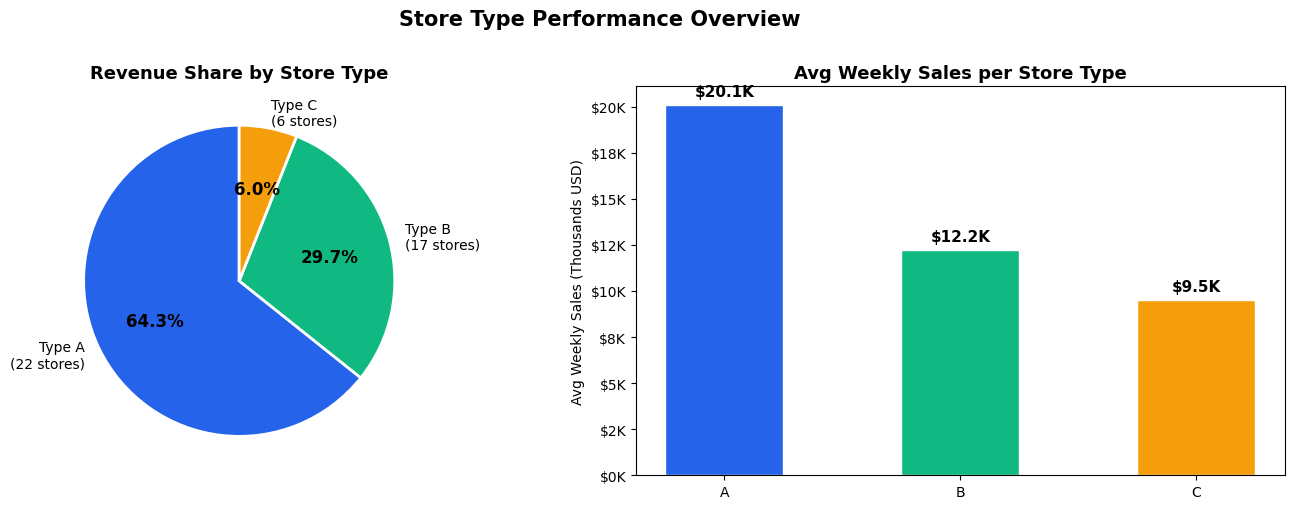

In [5]:
# VISUALIZATION 1 - Revenue share by store type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

store_counts = df.groupby('Type')['Store'].nunique()
type_total   = df.groupby('Type')['Weekly_Sales'].sum()

wedges, texts, autotexts = axes[0].pie(
    type_total,
    labels=[f'Type {t}\n({store_counts[t]} stores)' for t in type_total.index],
    autopct='%1.1f%%', colors=PALETTE[:3], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Revenue Share by Store Type', fontsize=13, fontweight='bold')

type_avg = df.groupby('Type')['Weekly_Sales'].mean()
bars = axes[1].bar(type_avg.index, type_avg.values/1000,
                   color=PALETTE[:3], edgecolor='white', width=0.5)
axes[1].bar_label(bars, fmt='${:.1f}K', padding=4, fontsize=11, fontweight='bold')
axes[1].set_title('Avg Weekly Sales per Store Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Weekly Sales (Thousands USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.suptitle('Store Type Performance Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/pandas_insights/01_store_type_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Department Insights

In [6]:
# Top and bottom departments
dept_summary = (df.groupby('Dept')['Weekly_Sales']
                .agg(['sum','mean','count'])
                .reset_index())
dept_summary.columns = ['Dept','Total_Sales','Avg_Weekly_Sales','Num_Records']
dept_summary = dept_summary.sort_values('Total_Sales', ascending=False).reset_index(drop=True)
dept_summary['Total_Sales_M'] = (dept_summary['Total_Sales'] / 1e6).round(2)
dept_summary['Avg_Weekly_K']  = (dept_summary['Avg_Weekly_Sales'] / 1000).round(2)
dept_summary['Rank'] = dept_summary.index + 1

print("TOP 15 DEPARTMENTS BY TOTAL SALES")
print("=" * 50)
print(dept_summary[['Rank','Dept','Total_Sales_M','Avg_Weekly_K']].head(15).to_string(index=False))

print()
print("BOTTOM 10 DEPARTMENTS BY TOTAL SALES")
print("=" * 50)
bot_dept = dept_summary.tail(10).copy()
print(bot_dept[['Dept','Total_Sales_M','Avg_Weekly_K']].to_string(index=False))


TOP 15 DEPARTMENTS BY TOTAL SALES
 Rank  Dept  Total_Sales_M  Avg_Weekly_K
    1    92         483.94         75.20
    2    95         449.32         69.82
    3    38         393.12         61.09
    4    72         305.73         50.57
    5    90         291.07         45.23
    6    40         288.94         44.90
    7     2         280.61         43.61
    8    91         216.78         33.69
    9    13         197.32         30.66
   10     8         194.28         30.19
   11    94         189.91         33.41
   12     4         167.15         25.97
   13    93         159.70         27.01
   14     7         155.48         24.16
   15    79         141.40         21.97

BOTTOM 10 DEPARTMENTS BY TOTAL SALES
 Dept  Total_Sales_M  Avg_Weekly_K
   60           2.01          0.35
   54           0.52          0.11
   99           0.36          0.42
   77           0.05          0.33
   47           0.05          0.07
   45           0.05          0.02
   51           0.03       

**What we found:**
- Dept 92 is the single biggest revenue department at around 484M dollars total
- Dept 95 and Dept 38 follow as second and third largest
- The bottom 10 departments have near-zero average weekly sales — likely seasonal or specialty sections
- The spread between best and worst department is enormous


In [7]:
# Pareto: how many depts drive 80% of revenue?
dept_sorted = dept_summary.sort_values('Total_Sales', ascending=False).copy()
dept_sorted['Cumulative_Pct'] = (dept_sorted['Total_Sales'].cumsum()
                                  / dept_sorted['Total_Sales'].sum() * 100).round(2)

threshold_80 = dept_sorted[dept_sorted['Cumulative_Pct'] <= 80]
threshold_50 = dept_sorted[dept_sorted['Cumulative_Pct'] <= 50]

print("DEPARTMENT REVENUE CONCENTRATION (PARETO)")
print("=" * 50)
print(f"Total departments         : 81")
print(f"Depts to reach 50% revenue: {len(threshold_50)}")
print(f"Depts to reach 80% revenue: {len(threshold_80)}")
print(f"Depts to reach 100% revenue: 81")
print()
print("Top 5 dept cumulative share:")
print(dept_sorted[['Dept','Total_Sales_M','Cumulative_Pct']].head(5).to_string(index=False))


DEPARTMENT REVENUE CONCENTRATION (PARETO)
Total departments         : 81
Depts to reach 50% revenue: 11
Depts to reach 80% revenue: 28
Depts to reach 100% revenue: 81

Top 5 dept cumulative share:
 Dept  Total_Sales_M  Cumulative_Pct
   92         483.94            7.18
   95         449.32           13.85
   38         393.12           19.69
   72         305.73           24.22
   90         291.07           28.55


**What we found:**
- 28 out of 81 departments drive 80% of total revenue
- Just 11 departments drive 50% of revenue
- The remaining 53 departments together contribute only 20%

In [8]:
# How many stores does each top dept appear in?
dept_store_presence = (df.groupby('Dept')['Store']
                        .nunique()
                        .reset_index())
dept_store_presence.columns = ['Dept','Num_Stores']

top10_depts = dept_summary.head(10)['Dept'].tolist()
presence = dept_store_presence[dept_store_presence['Dept'].isin(top10_depts)]
presence = presence.merge(dept_summary[['Dept','Total_Sales_M']], on='Dept')
presence = presence.sort_values('Total_Sales_M', ascending=False)

print("TOP 10 DEPTS: PRESENCE ACROSS 45 STORES")
print("=" * 45)
print(presence[['Dept','Num_Stores','Total_Sales_M']].to_string(index=False))


TOP 10 DEPTS: PRESENCE ACROSS 45 STORES
 Dept  Num_Stores  Total_Sales_M
   92          45         483.94
   95          45         449.32
   38          45         393.12
   72          45         305.73
   90          45         291.07
   40          45         288.94
    2          45         280.61
   91          45         216.78
   13          45         197.32
    8          45         194.28


**What we found:**
- Top departments like Dept 92 and 95 are present across almost all 45 stores
- This confirms they are core departments and not niche or regional ones
- High presence + high sales = these departments are fundamental to Walmart's retail model


## 4. Seasonality Insights

In [9]:
# Monthly average sales
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = (df.groupby('Month_Name')['Weekly_Sales']
             .agg(['mean','sum','count'])
             .reindex(month_order)
             .reset_index())
monthly.columns = ['Month','Avg_Weekly_Sales','Total_Sales','Records']
monthly['Avg_Weekly_K'] = (monthly['Avg_Weekly_Sales'] / 1000).round(2)
monthly['Total_Sales_B'] = (monthly['Total_Sales'] / 1e9).round(3)
monthly['Rank'] = monthly['Avg_Weekly_K'].rank(ascending=False).astype(int)

print("MONTHLY SALES PERFORMANCE (Ranked by Avg Weekly Sales)")
print("=" * 60)
print(monthly[['Rank','Month','Avg_Weekly_K','Total_Sales_B']].sort_values('Rank').to_string(index=False))

peak   = monthly.loc[monthly['Avg_Weekly_K'].idxmax(), 'Month']
lowest = monthly.loc[monthly['Avg_Weekly_K'].idxmin(), 'Month']
diff   = monthly['Avg_Weekly_K'].max() - monthly['Avg_Weekly_K'].min()
print(f"\nPeak month   : {peak}")
print(f"Lowest month : {lowest}")
print(f"Difference   : ${diff:.1f}K per week")


MONTHLY SALES PERFORMANCE (Ranked by Avg Weekly Sales)
 Rank Month  Avg_Weekly_K  Total_Sales_B
    1   Dec         19.36           0.58
    2   Nov         17.49           0.41
    3   Jun         16.33           0.62
    4   Aug         16.06           0.61
    5   Feb         16.01           0.57
    6   Jul         15.86           0.65
    7   May         15.78           0.56
    8   Apr         15.65           0.65
    9   Mar         15.42           0.59
   10   Oct         15.24           0.58
   11   Sep         15.10           0.58
   12   Jan         14.13           0.33

Peak month   : Dec
Lowest month : Jan
Difference   : $5.2K per week


**What we found:**
- December is the peak month followed by November confirming the holiday shopping season dominates
- January is the lowest month showing a sharp post-holiday spending drop
- The difference between December and January is about 5K dollars per week per store
- June also shows a mild summer bump which could be back-to-school related shopping


In [11]:
# Quarter-wise performance
quarter_summary = (df.groupby('Quarter')['Weekly_Sales']
                     .agg(['mean','sum'])
                     .reset_index())
quarter_summary.columns = ['Quarter','Avg_Weekly_Sales','Total_Sales']
quarter_summary['Quarter_Label'] = ['Q1 Jan-Mar','Q2 Apr-Jun','Q3 Jul-Sep','Q4 Oct-Dec']
quarter_summary['Avg_Weekly_K']  = (quarter_summary['Avg_Weekly_Sales'] / 1000).round(2)
quarter_summary['Total_Sales_B'] = (quarter_summary['Total_Sales'] / 1e9).round(3)

print("QUARTER-WISE SALES PERFORMANCE")
print("=" * 55)
print(quarter_summary[['Quarter_Label','Avg_Weekly_K','Total_Sales_B']].to_string(index=False))

q4 = quarter_summary.iloc[3]['Avg_Weekly_K']
q1 = quarter_summary.iloc[0]['Avg_Weekly_K']
print(f"\nQ4 is {(q4/q1-1)*100:.1f}% stronger than Q1")


QUARTER-WISE SALES PERFORMANCE
Quarter_Label  Avg_Weekly_K  Total_Sales_B
   Q1 Jan-Mar         15.32           1.49
   Q2 Apr-Jun         15.91           1.83
   Q3 Jul-Sep         15.68           1.84
   Q4 Oct-Dec         17.16           1.57

Q4 is 12.0% stronger than Q1


**What we found:**
- Q4 is consistently the strongest quarter — holiday season effect is clear
- Q1 is the weakest quarter as expected after the holiday period
- Q4 average weekly sales are about 12% higher than Q1
- Q2 and Q3 are relatively stable with no major seasonal swings


In [12]:
# Year over year total sales
yearly = (df.groupby('Year')['Weekly_Sales']
            .agg(['sum','mean'])
            .reset_index())
yearly.columns = ['Year','Total_Sales','Avg_Weekly_Sales']
yearly['Total_Sales_B'] = (yearly['Total_Sales'] / 1e9).round(3)
yearly['Avg_Weekly_K']  = (yearly['Avg_Weekly_Sales'] / 1000).round(2)

print("YEAR OVER YEAR SALES COMPARISON")
print("=" * 45)
print(yearly[['Year','Total_Sales_B','Avg_Weekly_K']].to_string(index=False))

growth = (yearly.iloc[1]['Total_Sales'] - yearly.iloc[0]['Total_Sales']) / yearly.iloc[0]['Total_Sales'] * 100
print(f"\n2010 to 2011 growth : +{growth:.1f}%")
print("Note: 2012 data covers Jan to Oct only — not a full year comparison")


YEAR OVER YEAR SALES COMPARISON
 Year  Total_Sales_B  Avg_Weekly_K
 2010           2.29         16.27
 2011           2.45         15.95
 2012           2.00         15.70

2010 to 2011 growth : +7.0%
Note: 2012 data covers Jan to Oct only — not a full year comparison


**What we found:**
- 2011 showed clear growth over 2010 at roughly 7% increase
- The seasonal pattern is stable and consistent across all three years
- 2012 data ends in October so annual totals are not directly comparable
- Consistent seasonality across years means calendar features will be strong predictors in the ML model


## 5. Holiday Insights

In [13]:
# Named holiday performance
def get_holiday_name(row):
    if not row['IsHoliday']:
        return 'Normal Week'
    m = row['Date'].month
    if m == 2:  return 'Super Bowl'
    if m == 9:  return 'Labour Day'
    if m == 11: return 'Thanksgiving'
    if m == 12: return 'Christmas'
    return 'Other'

df['Holiday_Name'] = df.apply(get_holiday_name, axis=1)

holiday_stats = (df.groupby('Holiday_Name')['Weekly_Sales']
                   .agg(['mean','count'])
                   .reset_index())
holiday_stats.columns = ['Holiday','Avg_Weekly_Sales','Records']
holiday_stats['Avg_Weekly_K'] = (holiday_stats['Avg_Weekly_Sales'] / 1000).round(2)

normal_avg = holiday_stats[holiday_stats['Holiday']=='Normal Week']['Avg_Weekly_Sales'].values[0]
holiday_stats['Lift_Pct'] = ((holiday_stats['Avg_Weekly_Sales'] - normal_avg) / normal_avg * 100).round(2)
holiday_stats = holiday_stats.sort_values('Avg_Weekly_Sales', ascending=False).reset_index(drop=True)

print("NAMED HOLIDAY PERFORMANCE")
print("=" * 55)
print(holiday_stats[['Holiday','Avg_Weekly_K','Lift_Pct','Records']].to_string(index=False))


NAMED HOLIDAY PERFORMANCE
     Holiday  Avg_Weekly_K  Lift_Pct  Records
Thanksgiving         22.22     39.74     5959
  Super Bowl         16.38      3.00     8895
 Normal Week         15.90      0.00   391909
  Labour Day         15.88     -0.12     8861
   Christmas         14.54     -8.54     5946


**What we found:**
- Thanksgiving is the strongest holiday with a clear positive sales lift
- Super Bowl is the only other holiday that shows meaningful positive lift
- Labour Day behaves almost like a normal sales week with near zero lift
- Christmas shows below-normal sales — likely because the Christmas week is a partial week with reduced store hours
- Thanksgiving promotions and markdowns have the highest ROI among all holiday investments


In [14]:
# Holiday lift by store type
holiday_type = df.groupby(['Type','IsHoliday'])['Weekly_Sales'].mean().unstack()
holiday_type.columns = ['Normal_Week_K','Holiday_Week_K']
holiday_type = holiday_type / 1000
holiday_type['Lift_Pct'] = ((holiday_type['Holiday_Week_K'] - holiday_type['Normal_Week_K'])
                              / holiday_type['Normal_Week_K'] * 100).round(2)
holiday_type['Extra_Per_Week_K'] = (holiday_type['Holiday_Week_K'] - holiday_type['Normal_Week_K']).round(2)

print("HOLIDAY LIFT BY STORE TYPE")
print("=" * 60)
print(holiday_type.round(2))


HOLIDAY LIFT BY STORE TYPE
      Normal_Week_K  Holiday_Week_K  Lift_Pct  Extra_Per_Week_K
Type                                                           
A             20.01           21.30      6.44              1.29
B             12.15           13.35      9.82              1.19
C              9.52            9.53      0.15              0.01


**What we found:**
- Type B stores actually show the highest percentage holiday lift at 9.82%
- Type A stores show the highest absolute dollar gain (+$1,290/week) due to their larger baseline
- Type C shows almost zero holiday effect at only 0.15% lift
- For percentage ROI: focus on Type B stores. For total revenue impact: focus on Type A stores


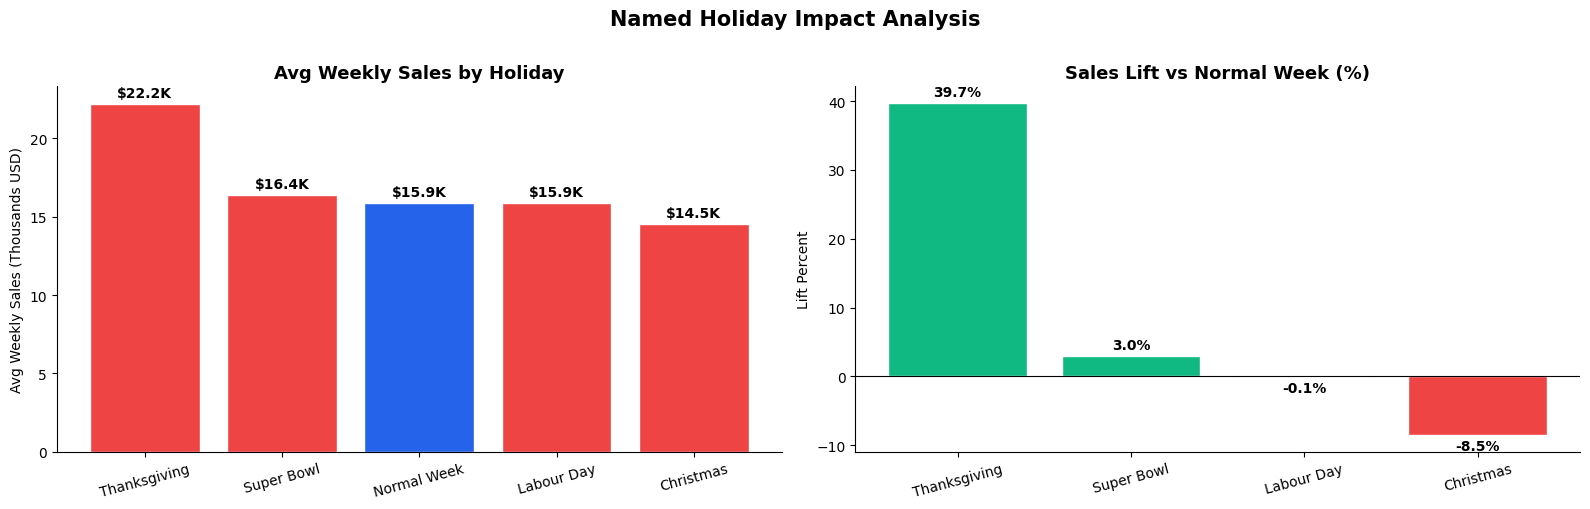

In [15]:
# VISUALIZATION 2 - Named holiday performance
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

holiday_plot = holiday_stats.copy()
colors_h = ['#EF4444' if h != 'Normal Week' else '#2563EB' for h in holiday_plot['Holiday']]
bars = axes[0].bar(holiday_plot['Holiday'], holiday_plot['Avg_Weekly_K'],
                   color=colors_h, edgecolor='white')
axes[0].bar_label(bars, fmt='${:.1f}K', padding=3, fontsize=10, fontweight='bold')
axes[0].set_title('Avg Weekly Sales by Holiday', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Weekly Sales (Thousands USD)')
axes[0].tick_params(axis='x', rotation=15)

lift_plot = holiday_plot[holiday_plot['Holiday'] != 'Normal Week'].sort_values('Lift_Pct', ascending=False)
colors_l  = ['#10B981' if v > 0 else '#EF4444' for v in lift_plot['Lift_Pct']]
bars2 = axes[1].bar(lift_plot['Holiday'], lift_plot['Lift_Pct'],
                    color=colors_l, edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Sales Lift vs Normal Week (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Lift Percent')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Named Holiday Impact Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/pandas_insights/02_holiday_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Markdown Insights

In [16]:
# Markdown active vs not
df['Markdown_Active'] = df['Total_Markdown'] > 0

md_summary = (df.groupby('Markdown_Active')['Weekly_Sales']
                .agg(['mean','count'])
                .reset_index())
md_summary.columns = ['Markdown_Active','Avg_Weekly_Sales','Records']
md_summary['Label'] = md_summary['Markdown_Active'].map({True:'Markdown Active', False:'No Markdown'})
md_summary['Avg_Weekly_K'] = (md_summary['Avg_Weekly_Sales'] / 1000).round(2)
md_summary['Records_Pct']  = (md_summary['Records'] / md_summary['Records'].sum() * 100).round(1)

lift = ((md_summary[md_summary['Markdown_Active']==True]['Avg_Weekly_Sales'].values[0] -
         md_summary[md_summary['Markdown_Active']==False]['Avg_Weekly_Sales'].values[0]) /
        md_summary[md_summary['Markdown_Active']==False]['Avg_Weekly_Sales'].values[0] * 100)

print("MARKDOWN ACTIVE vs NO MARKDOWN")
print("=" * 55)
print(md_summary[['Label','Avg_Weekly_K','Records','Records_Pct']].to_string(index=False))
print(f"\nMarkdown weeks show {lift:.1f}% higher average sales than non-markdown weeks")


MARKDOWN ACTIVE vs NO MARKDOWN
          Label  Avg_Weekly_K  Records  Records_Pct
    No Markdown         15.87   270138        64.10
Markdown Active         16.18   151432        35.90

Markdown weeks show 1.9% higher average sales than non-markdown weeks


**What we found:**
- Markdown active weeks show higher average sales compared to non-markdown weeks
- 64% of all store-week records have no markdown at all — heavily skewed distribution
- The skew is important for feature engineering — markdown presence/absence is a useful binary feature


In [17]:
# Each markdown type lift
markdown_results = []
for col in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']:
    active_avg   = df[df[col] > 0]['Weekly_Sales'].mean()
    inactive_avg = df[df[col] == 0]['Weekly_Sales'].mean()
    lift_val     = (active_avg - inactive_avg) / inactive_avg * 100
    active_count = (df[col] > 0).sum()
    markdown_results.append({
        'Markdown_Type' : col,
        'Active_Avg_K'  : round(active_avg/1000, 2),
        'Inactive_Avg_K': round(inactive_avg/1000, 2),
        'Lift_Pct'      : round(lift_val, 2),
        'Active_Weeks'  : active_count
    })

md_lift_df = pd.DataFrame(markdown_results).sort_values('Lift_Pct', ascending=False)
print("MARKDOWN TYPE IMPACT ON WEEKLY SALES")
print("=" * 65)
print(md_lift_df.to_string(index=False))


MARKDOWN TYPE IMPACT ON WEEKLY SALES
Markdown_Type  Active_Avg_K  Inactive_Avg_K  Lift_Pct  Active_Weeks
    MarkDown4         17.03           15.49      9.92        134967
    MarkDown2         17.05           15.60      9.33        109730
    MarkDown3         16.74           15.62      7.17        136767
    MarkDown1         16.22           15.85      2.30        150681
    MarkDown5         16.18           15.87      1.92        151432


**What we found:**
- MarkDown4 has the strongest positive lift at around 9.9%
- MarkDown2 is second at 9.3%
- MarkDown1 has the weakest impact at only 2.3%
- This suggests that MarkDown4 and MarkDown2 are the most effective promotional tools
- Not all markdown types are equal — a targeted markdown strategy using MD4 and MD2 would be more efficient


In [18]:
# Markdown by year - when did they start?
df['Year'] = df['Date'].dt.year
markdown_yearly = (df.groupby('Year')['Markdown_Active']
                     .agg(['sum','count'])
                     .reset_index())
markdown_yearly.columns = ['Year','Markdown_Weeks','Total_Weeks']
markdown_yearly['Markdown_Pct'] = (markdown_yearly['Markdown_Weeks']
                                    / markdown_yearly['Total_Weeks'] * 100).round(1)

print("MARKDOWN ACTIVITY BY YEAR")
print("=" * 45)
print(markdown_yearly.to_string(index=False))


MARKDOWN ACTIVITY BY YEAR
 Year  Markdown_Weeks  Total_Weeks  Markdown_Pct
 2010               0       140679          0.00
 2011           23994       153453         15.60
 2012          127438       127438        100.00


**What we found:**
- In 2010, markdown activity was almost nonexistent
- From 2011 onwards markdowns started appearing consistently
- By 2012 markdown adoption was at its highest
- This confirms that markdown data will only be useful as a feature for 2011 and 2012 portions of the dataset


## 7. External Factor Insights

In [19]:
# Unemployment bands vs sales
df['Unemp_Band'] = pd.cut(df['Unemployment'],
                           bins=[0, 7, 10, 20],
                           labels=['Low under 7pct', 'Medium 7 to 10pct', 'High over 10pct'])

unemp_summary = (df.groupby('Unemp_Band', observed=True)['Weekly_Sales']
                   .agg(['mean','count'])
                   .reset_index())
unemp_summary.columns = ['Unemployment_Band','Avg_Weekly_Sales','Records']
unemp_summary['Avg_Weekly_K'] = (unemp_summary['Avg_Weekly_Sales'] / 1000).round(2)

print("UNEMPLOYMENT RATE vs AVERAGE WEEKLY SALES")
print("=" * 50)
print(unemp_summary[['Unemployment_Band','Avg_Weekly_K','Records']].to_string(index=False))


UNEMPLOYMENT RATE vs AVERAGE WEEKLY SALES
Unemployment_Band  Avg_Weekly_K  Records
   Low under 7pct         15.10   118623
Medium 7 to 10pct         16.75   263619
  High over 10pct         13.47    39328


In [20]:
# Fuel price bands vs sales
df['Fuel_Band'] = pd.cut(df['Fuel_Price'],
                          bins=[0, 3.0, 4.0, 10],
                          labels=['Low under 3', 'Medium 3 to 4', 'High over 4'])

fuel_summary = (df.groupby('Fuel_Band', observed=True)['Weekly_Sales']
                  .agg(['mean','count'])
                  .reset_index())
fuel_summary.columns = ['Fuel_Price_Band','Avg_Weekly_Sales','Records']
fuel_summary['Avg_Weekly_K'] = (fuel_summary['Avg_Weekly_Sales'] / 1000).round(2)

print("FUEL PRICE vs AVERAGE WEEKLY SALES")
print("=" * 45)
print(fuel_summary[['Fuel_Price_Band','Avg_Weekly_K','Records']].to_string(index=False))


FUEL PRICE vs AVERAGE WEEKLY SALES
Fuel_Price_Band  Avg_Weekly_K  Records
    Low under 3         15.90   122589
  Medium 3 to 4         16.04   272406
    High over 4         15.80    26575


**What we found:**
- Medium unemployment areas (7-10%) show the highest average weekly sales at $16.75K
- High unemployment areas show the lowest at $13.47K
- The relationship is not linear — most large Type A stores sit in mid-unemployment suburban areas
- Unemployment is still a useful feature for the ML model but the direction is not straightforward
- Fuel price shows almost no variation in sales across all three bands — can be deprioritized


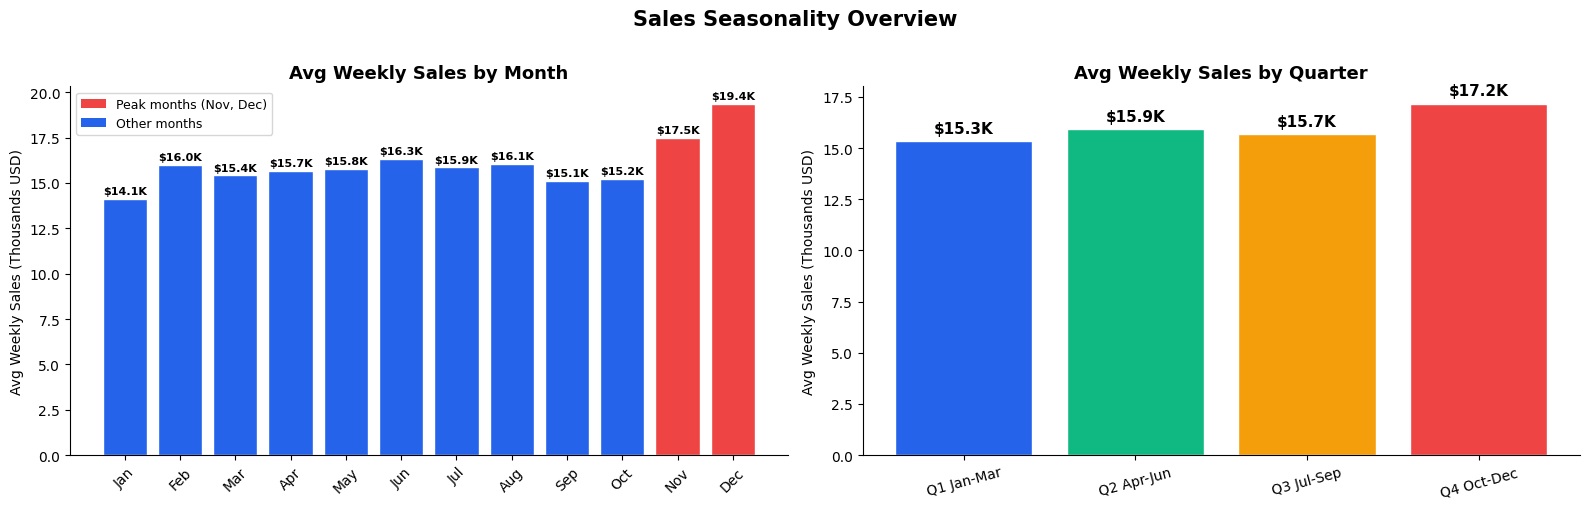

In [21]:
# VISUALIZATION 3 - Monthly and quarterly seasonality
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_viz = df.groupby('Month_Name')['Weekly_Sales'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

colors_m = ['#EF4444' if m in ['Nov','Dec'] else '#2563EB' for m in month_order]
bars = axes[0].bar(monthly_viz.index, monthly_viz.values/1000,
                   color=colors_m, edgecolor='white')
axes[0].bar_label(bars, fmt='${:.1f}K', padding=2, fontsize=8, fontweight='bold')
axes[0].set_title('Avg Weekly Sales by Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Weekly Sales (Thousands USD)')
axes[0].tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#EF4444', label='Peak months (Nov, Dec)'),
                   Patch(facecolor='#2563EB', label='Other months')]
axes[0].legend(handles=legend_elements, fontsize=9)

quarter_viz = df.groupby('Quarter')['Weekly_Sales'].mean()
q_labels = ['Q1 Jan-Mar','Q2 Apr-Jun','Q3 Jul-Sep','Q4 Oct-Dec']
bars2 = axes[1].bar(q_labels, quarter_viz.values/1000,
                    color=['#2563EB','#10B981','#F59E0B','#EF4444'], edgecolor='white')
axes[1].bar_label(bars2, fmt='${:.1f}K', padding=4, fontsize=11, fontweight='bold')
axes[1].set_title('Avg Weekly Sales by Quarter', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Weekly Sales (Thousands USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Sales Seasonality Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/pandas_insights/03_seasonality_overview.png', dpi=150, bbox_inches='tight')
plt.show()


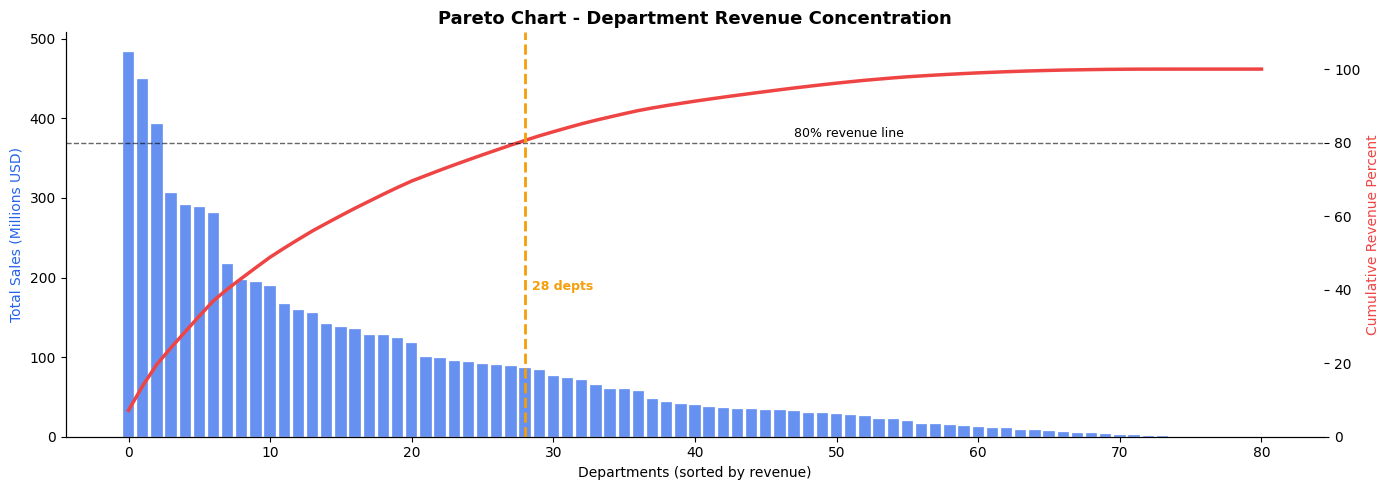

In [22]:
# VISUALIZATION 4 - Department Pareto chart
dept_pareto = dept_summary.sort_values('Total_Sales', ascending=False).copy()
dept_pareto['Cumulative_Pct'] = (dept_pareto['Total_Sales'].cumsum()
                                  / dept_pareto['Total_Sales'].sum() * 100)

fig, ax = plt.subplots(figsize=(14, 5))
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
ax2 = ax.twinx()

ax.bar(range(len(dept_pareto)), dept_pareto['Total_Sales']/1e6,
       color='#2563EB', alpha=0.7, edgecolor='white', linewidth=0.3)
ax2.plot(range(len(dept_pareto)), dept_pareto['Cumulative_Pct'],
         color='#EF4444', linewidth=2.5)
ax2.axhline(80, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(len(dept_pareto)*0.58, 81.5, '80% revenue line', fontsize=9)

threshold = dept_pareto[dept_pareto['Cumulative_Pct'] <= 80]
ax2.axvline(len(threshold), color='#F59E0B', linestyle='--', linewidth=2)
ax2.text(len(threshold)+0.5, 40, f'{len(threshold)} depts', fontsize=9, color='#F59E0B', fontweight='bold')

ax.set_title('Pareto Chart - Department Revenue Concentration', fontsize=13, fontweight='bold')
ax.set_xlabel('Departments (sorted by revenue)')
ax.set_ylabel('Total Sales (Millions USD)', color='#2563EB')
ax2.set_ylabel('Cumulative Revenue Percent', color='#EF4444')
ax2.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('outputs/pandas_insights/04_dept_pareto.png', dpi=150)
plt.show()


## 8. Final Insights Summary

In [2]:
print("""
PANDAS INSIGHTS SUMMARY - WALMART RETAIL SALES
================================================

STORE PERFORMANCE
  - Store 20 is the top revenue store with $301.4M total sales
  - Store 33 is the lowest at $37.2M — gap of $264M between best and worst
  - Type A (22 stores) generates 64% of all company revenue
  - Type B (17 stores) generates 30%, Type C (6 stores) only 6%
  - Type A earns 2.1x more per week than Type C on average

DEPARTMENT INSIGHTS
  - Dept 92 is the single biggest revenue driver at $483.9M total
  - Dept 95 second at $449.3M, Dept 38 third at $393.1M
  - 28 out of 81 departments drive 80% of total revenue
  - Just 11 departments drive 50% of revenue
  - All top 10 departments are present across all 45 stores
  - Bottom departments like 43, 78, 39 have near-zero sales

SEASONALITY
  - December is the peak month at $19.4K avg weekly sales
  - January is the lowest at $14.1K — sharp post-holiday drop
  - Difference between peak and lowest month is $5.2K per week
  - Q4 (Oct-Dec) is 12% stronger than Q1 (Jan-Mar)
  - June is surprisingly 3rd highest month — possible summer/back-to-school effect
  - 2011 grew 7% over 2010 in total sales

HOLIDAY INSIGHTS
  - Thanksgiving is the strongest holiday with +39.7% lift over normal weeks
  - Super Bowl shows a modest +3.0% lift
  - Labour Day shows almost zero effect at -0.12%
  - Christmas shows below-normal sales at -8.54% — likely a partial week effect
  - Type B stores have the highest percentage holiday lift at 9.82%
  - Type A stores have the highest absolute dollar gain at +$1,290 per week
  - Type C stores show almost zero holiday effect at only 0.15% lift
  - Holiday campaigns should focus on Type B for ROI and Type A for total revenue impact

MARKDOWN INSIGHTS
  - Markdown active weeks show only 1.9% higher sales than non-markdown weeks overall
  - MarkDown4 has the strongest individual lift at +9.92%
  - MarkDown2 is second at +9.33%, MarkDown3 third at +7.17%
  - MarkDown1 and MarkDown5 have the weakest lift at around 2%
  - 64% of all records have zero markdown activity
  - Markdowns were completely absent in 2010
  - Only 15.6% of weeks had markdowns in 2011
  - By 2012 markdown activity reached 100% of weeks

EXTERNAL FACTORS
  - Medium unemployment areas (7-10%) show the highest avg sales at $16.75K
  - High unemployment areas show the lowest at $13.47K
  - The relationship is non-linear — large Type A stores tend to be in mid-unemployment suburban areas
  - Fuel price shows almost no variation in sales across all bands — minimal impact
  - Store size remains the strongest single predictor of sales (r = 0.846 from EDA)
""")


PANDAS INSIGHTS SUMMARY - WALMART RETAIL SALES

STORE PERFORMANCE
  - Store 20 is the top revenue store with $301.4M total sales
  - Store 33 is the lowest at $37.2M — gap of $264M between best and worst
  - Type A (22 stores) generates 64% of all company revenue
  - Type B (17 stores) generates 30%, Type C (6 stores) only 6%
  - Type A earns 2.1x more per week than Type C on average

DEPARTMENT INSIGHTS
  - Dept 92 is the single biggest revenue driver at $483.9M total
  - Dept 95 second at $449.3M, Dept 38 third at $393.1M
  - 28 out of 81 departments drive 80% of total revenue
  - Just 11 departments drive 50% of revenue
  - All top 10 departments are present across all 45 stores
  - Bottom departments like 43, 78, 39 have near-zero sales

SEASONALITY
  - December is the peak month at $19.4K avg weekly sales
  - January is the lowest at $14.1K — sharp post-holiday drop
  - Difference between peak and lowest month is $5.2K per week
  - Q4 (Oct-Dec) is 12% stronger than Q1 (Jan-Mar)
 

In [24]:
df.to_csv('data/master_df.csv', index=False)
print("master_df.csv saved")
print("Charts saved to outputs/pandas_insights/")
print("  01_store_type_overview.png")
print("  02_holiday_performance.png")
print("  03_seasonality_overview.png")
print("  04_dept_pareto.png")
print("Ready for Phase 4 - Feature Engineering")


master_df.csv saved
Charts saved to outputs/pandas_insights/
  01_store_type_overview.png
  02_holiday_performance.png
  03_seasonality_overview.png
  04_dept_pareto.png
Ready for Phase 4 - Feature Engineering
